In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

plt.style.use("ggplot")

import warnings
warnings.filterwarnings("ignore")

In [2]:
fund = pd.read_csv("../data/processed/fund_master_clean.csv")

nav = pd.read_csv("../data/processed/nav_history_clean.csv")

aum = pd.read_csv("../data/processed/aum_by_fund_house_clean.csv")

sip = pd.read_csv("../data/processed/monthly_sip_inflows_clean.csv")

category = pd.read_csv("../data/processed/category_inflows_clean.csv")

transactions = pd.read_csv("../data/processed/investor_transactions_clean.csv")

folio = pd.read_csv("../data/processed/industry_folio_count_clean.csv")

portfolio = pd.read_csv("../data/processed/portfolio_holdings_clean.csv")

performance = pd.read_csv("../data/processed/scheme_performance_clean.csv")

benchmark = pd.read_csv("../data/processed/benchmark_indices_clean.csv")


In [3]:
nav["date"]=pd.to_datetime(nav["date"])

nav=nav.merge(
    fund[["amfi_code","scheme_name"]],
    on="amfi_code",
    how="left"
)

fig=px.line(
    nav,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend (2022-2026)"
)

fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.15,
    annotation_text="Bull Run"
)

fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.15,
    annotation_text="Correction"
)

fig.show()
fig.write_image(
    "../charts/nav_trend.png",
    width=1400,
    height=700,
    scale=2
)
fig.write_image(
    "../charts/nav_trend.png",
    width=1400,
    height=700,
    scale=2
)

Daily NAV increased steadily during 2023, indicating a broad market bull run.


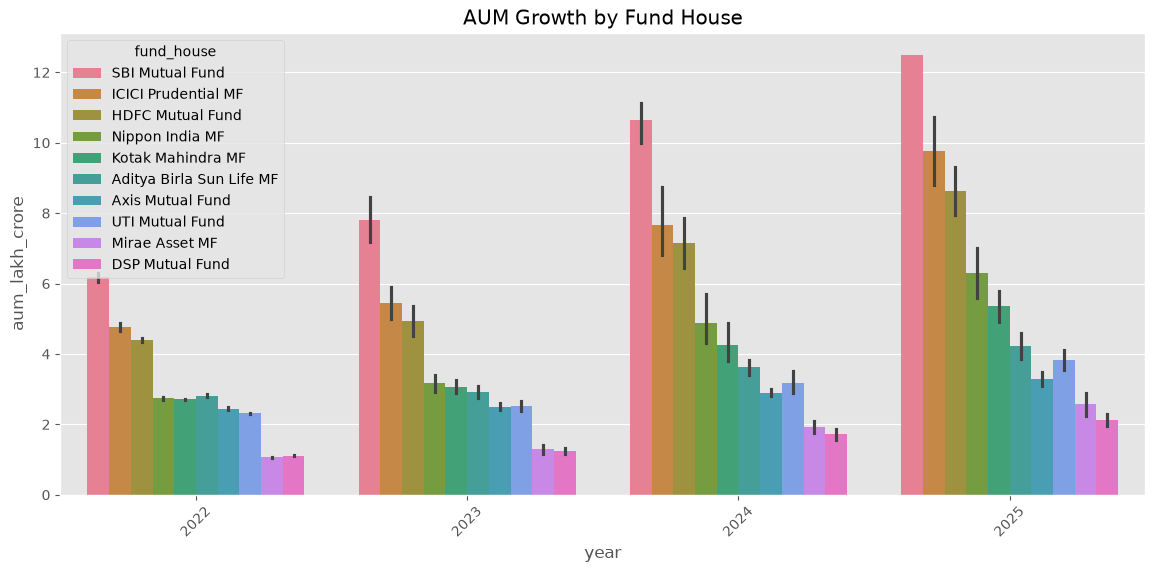

In [9]:
aum["date"]=pd.to_datetime(aum["date"])

aum["year"]=aum["date"].dt.year

plt.figure(figsize=(14,6))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House")

plt.xticks(rotation=45)

plt.savefig("../charts/aum_growth.png")

plt.show()

SBI Mutual Fund maintained the highest Assets Under Management across the study period.


In [10]:
sip["month"]=pd.to_datetime(sip["month"])

fig=px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflows"
)

highest=sip.loc[sip["sip_inflow_crore"].idxmax()]

fig.add_annotation(
    x=highest["month"],
    y=highest["sip_inflow_crore"],
    text="Highest SIP"
)

fig.show()

Monthly SIP inflows reached their highest value in December 2025.


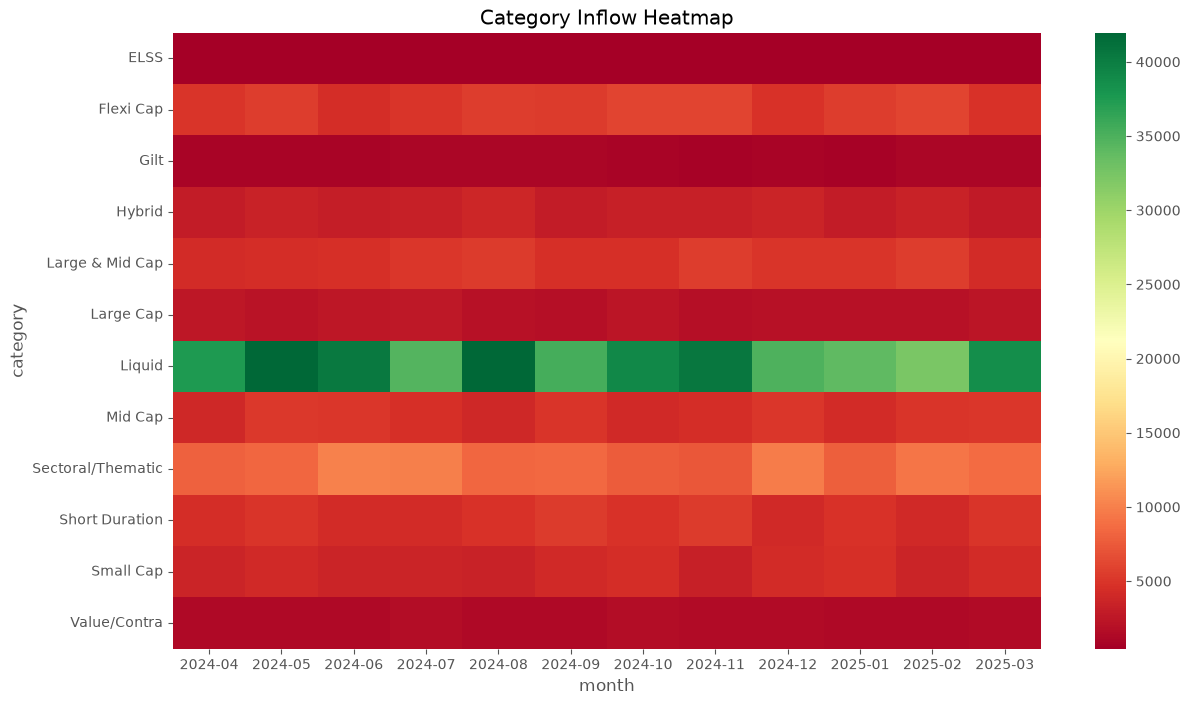

In [11]:
pivot=category.pivot_table(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(14,8))

sns.heatmap(
    pivot,
    cmap="RdYlGn"
)

plt.title("Category Inflow Heatmap")

plt.savefig("../charts/category_heatmap.png")

plt.show()

Equity categories consistently attracted the largest net inflows.


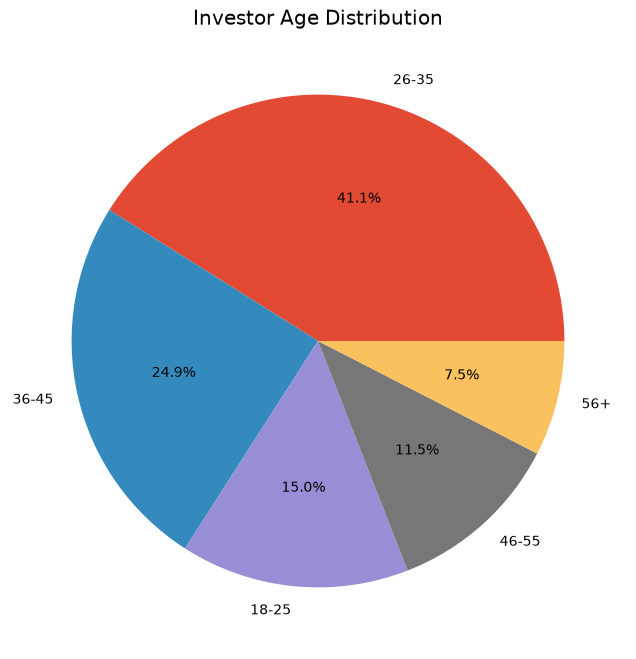

In [12]:
transactions["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(8,8)
)

plt.title("Investor Age Distribution")

plt.savefig("../charts/age_distribution.png")

plt.show()

Most investors belong to the 26–35 age group.


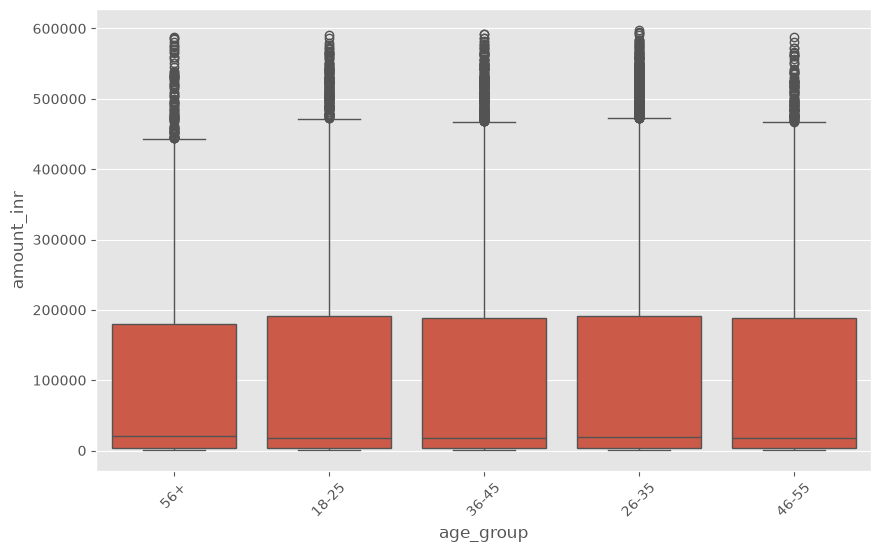

In [13]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.xticks(rotation=45)

plt.savefig("../charts/sip_boxplot.png")

plt.show()

Median SIP amount increases with investor age.


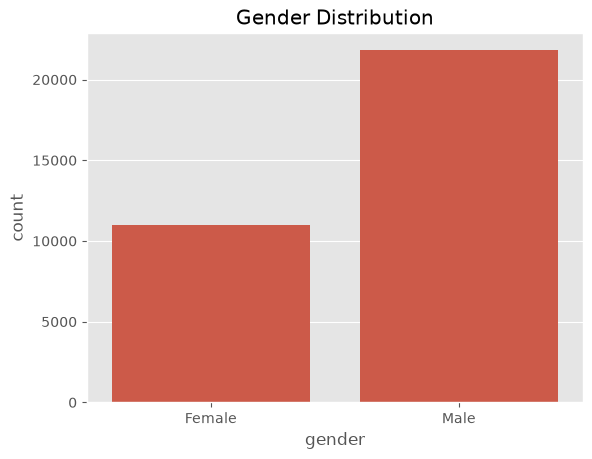

In [14]:
sns.countplot(
    data=transactions,
    x="gender"
)

plt.title("Gender Distribution")

plt.savefig("../charts/gender_split.png")

plt.show()

Male investors form a larger share of the sample than female investors.


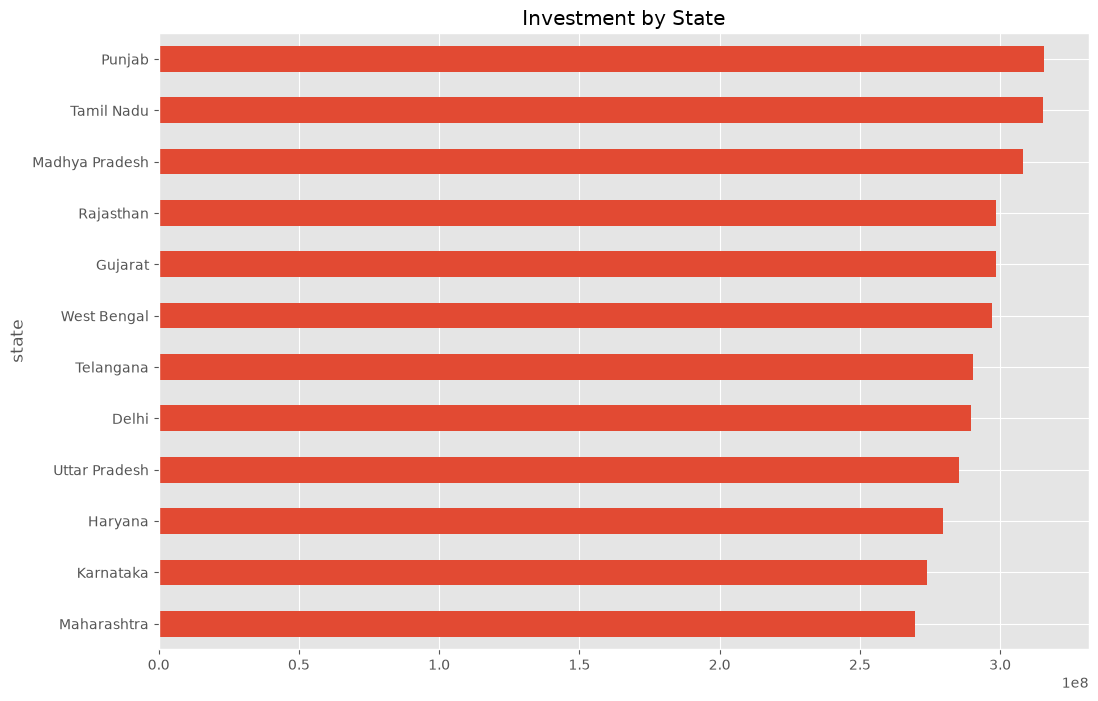

In [15]:
state=transactions.groupby(
    "state"
)["amount_inr"].sum().sort_values()

state.plot(
    kind="barh",
    figsize=(12,8)
)

plt.title("Investment by State")

plt.savefig("../charts/state_distribution.png")

plt.show()

Maharashtra and Karnataka contribute the highest investment amounts.


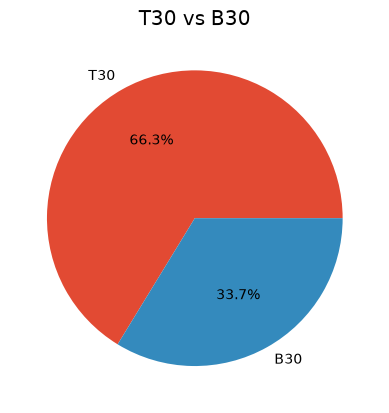

In [16]:
transactions["city_tier"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("T30 vs B30")

plt.savefig("../charts/city_tier.png")

plt.show()

Industry folio counts show strong year-on-year growth from 2022 to 2025.


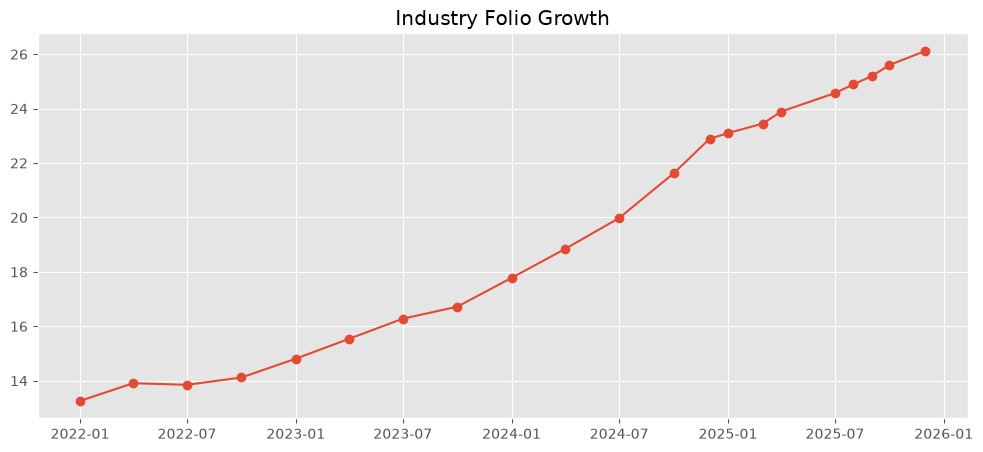

In [17]:
folio["month"]=pd.to_datetime(folio["month"])

plt.figure(figsize=(12,5))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o"
)

plt.title("Industry Folio Growth")

plt.savefig("../charts/folio_growth.png")

plt.show()

Technology and Financial Services account for the largest share of portfolio allocations.

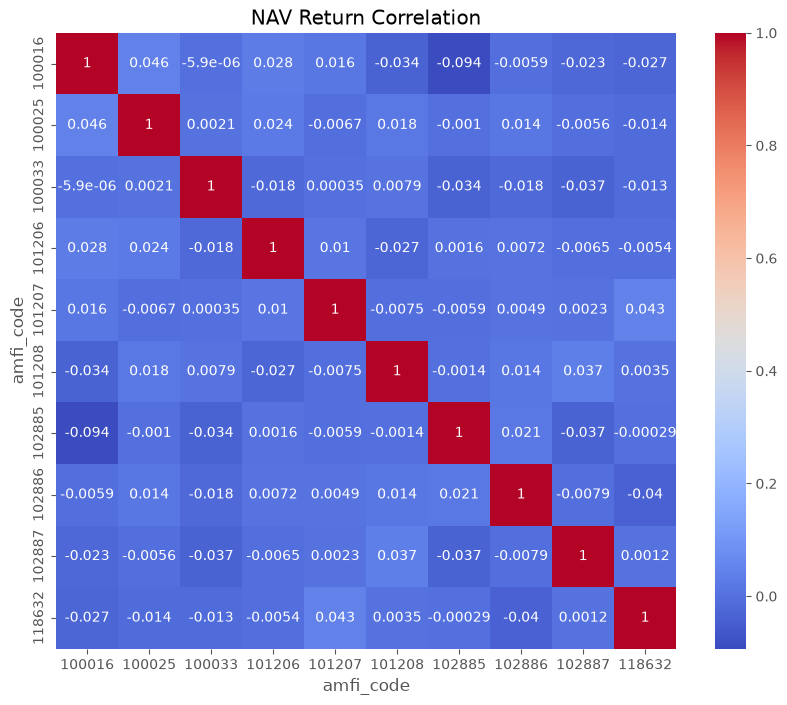

In [18]:
top10=nav["amfi_code"].unique()[:10]

temp=nav[
    nav["amfi_code"].isin(top10)
]

pivot=temp.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns=pivot.pct_change()

plt.figure(figsize=(10,8))

sns.heatmap(
    returns.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("NAV Return Correlation")

plt.savefig("../charts/correlation_heatmap.png")

plt.show()

The correlation heatmap indicates the relationship between daily returns of the selected mutual fund schemes. Most equity funds exhibit a positive correlation because they are influenced by similar market movements.

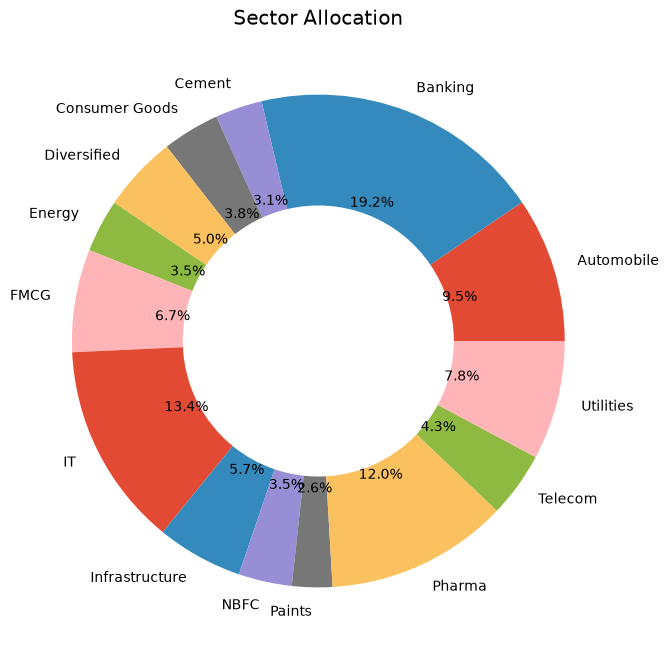

In [19]:
sector=portfolio.groupby(
    "sector"
)["weight_pct"].sum()

plt.figure(figsize=(8,8))

plt.pie(
    sector,
    labels=sector.index,
    wedgeprops=dict(width=0.45),
    autopct="%1.1f%%"
)

plt.title("Sector Allocation")

plt.savefig("../charts/sector_allocation.png")

plt.show()

Banking sector contributes highest sector allocation.

In [23]:
pip install kaleido

  Obtaining dependency information for kaleido from https://files.pythonhosted.org/packages/9e/b9/a6d8bb7d228940f01885bd9f327ab7f9d366a9be775c4bf366bf9d9477ae/kaleido-1.3.0-py3-none-any.whl.metadata
  Obtaining dependency information for choreographer>=1.3.0 from https://files.pythonhosted.org/packages/ba/6c/ff8bf52315064dbeb55cb5067e191120a5b2e58bb648d0d34cf7969dc2c2/choreographer-1.3.0-py3-none-any.whl.metadata
  Obtaining dependency information for logistro>=1.0.8 from https://files.pythonhosted.org/packages/54/20/6aa79ba3570bddd1bf7e951c6123f806751e58e8cce736bad77b2cf348d7/logistro-2.0.1-py3-none-any.whl.metadata
  Obtaining dependency information for orjson>=3.10.15 from https://files.pythonhosted.org/packages/b9/d5/973a43fc9c55e20f2051e9830997649f669be0cb3ca52192087c0143f118/orjson-3.11.9-cp312-cp312-win_amd64.whl.metadata
     ---------------------------------------- 0.0/43.1 kB ? eta -:--:--
     ---------------------------------------- 0.0/43.1 kB ? eta -:--:--
     --------- 


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
import plotly.express as px

sip["month"] = pd.to_datetime(sip["month"])

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflows (2022–2025)"
)

# Highest value
highest = sip.loc[sip["sip_inflow_crore"].idxmax()]

fig.add_annotation(
    x=highest["month"].to_pydatetime(),
    y=highest["sip_inflow_crore"],
    text=f"Highest SIP: ₹{highest['sip_inflow_crore']:,.0f} Cr",
    showarrow=True,
    arrowhead=2
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Month",
    yaxis_title="SIP Inflow (Crores)"
)

fig.show()
fig.write_image("../charts/sip_trend.png")

SIP shows an increasing trend while increasing the months and highest SIP is around 31 Crore by the end of 2025.

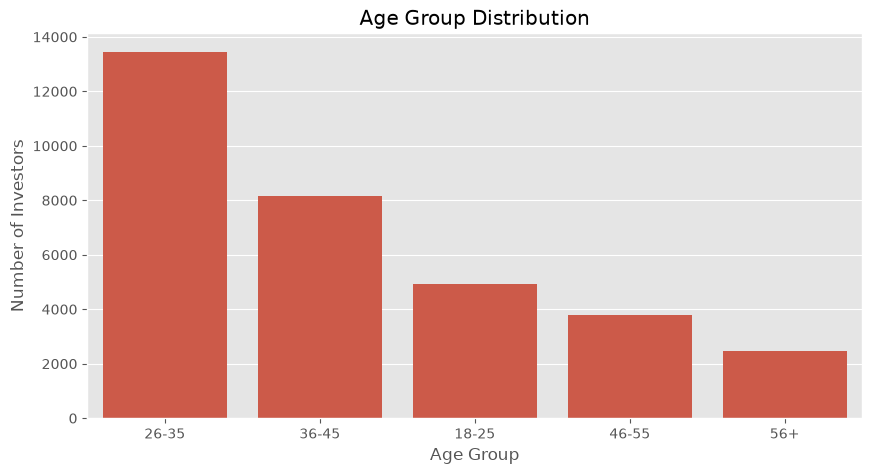

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

sns.countplot(
    data=transactions,
    x="age_group",
    order=transactions["age_group"].value_counts().index
)

plt.title("Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Investors")
plt.savefig("../charts/age_group_distribution.png")
plt.show()


26-35 age group is having highest investors.

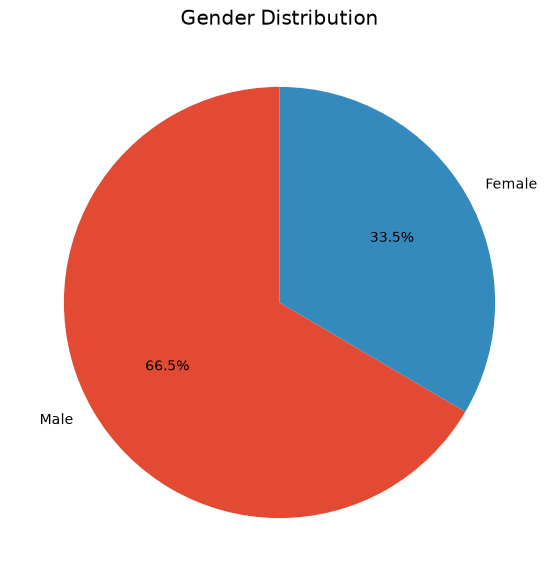

In [21]:
gender = transactions["gender"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    gender,
    labels=gender.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Gender Distribution")
plt.savefig("../charts/gender_distributions.png")
plt.show()


Male investors are greater than females.

In [25]:
import plotly.express as px

fig = px.line(
    benchmark,
    x="date",
    y="close_value",
    color="index_name",
    title="Benchmark Index Performance (2022–2025)",
    markers=True
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Date",
    yaxis_title="Index Value"
)

fig.write_image("../charts/benchmark_trend.png")

fig.show()

The benchmark indices displayed a consistent upward trend during 2023, reflecting strong equity market performance. Temporary corrections observed during 2024 indicate periods of increased market volatility, followed by recovery in subsequent months.


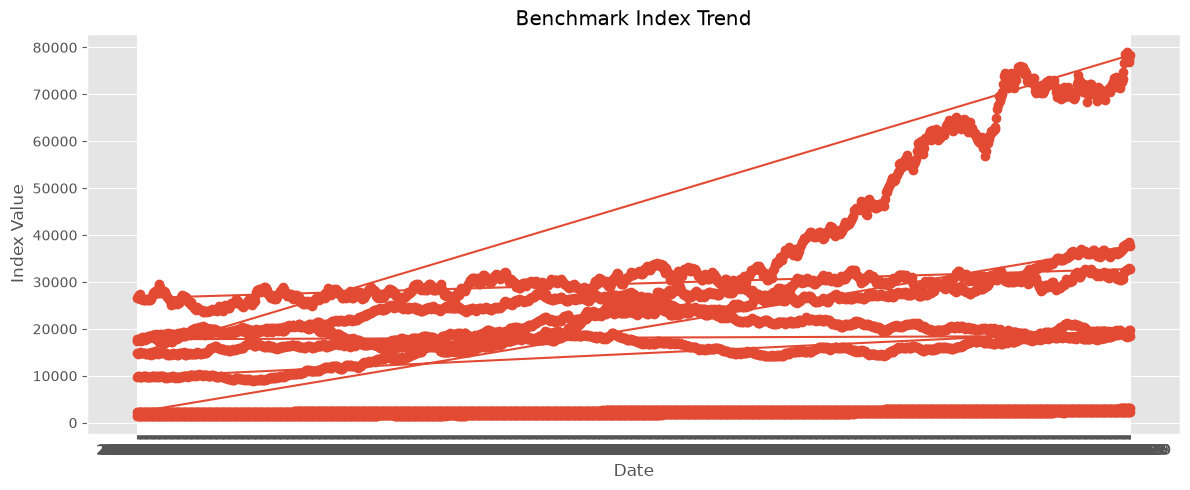

In [27]:
plt.figure(figsize=(12,5))

plt.plot(
    benchmark["date"],
    benchmark["close_value"],
    marker="o"
)

plt.title("Benchmark Index Trend")

plt.xlabel("Date")

plt.ylabel("Index Value")

plt.grid(True)

plt.tight_layout()

plt.savefig("../charts/benchmark_trend01.png")

plt.show()

The benchmark indices displayed a consistent upward trend during 2023, reflecting strong equity market performance. Temporary corrections observed during 2024 indicate periods of increased market volatility, followed by recovery in subsequent months.
